 Step 1: Import Libraries


In [1]:
import pandas as pd
import sqlite3


Step 2: Load Dataset


In [2]:


df = pd.read_csv(r'data\online_retail_cleaned_with_cohort.csv')

# مشاهده چند ردیف اول برای اطمینان از درستی بارگذاری



Step 3: Show First 5 Rows


In [3]:

df.head()



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceMonth,CohortMonth,CohortIndex
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-01,2010-12-01,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010-12-01,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-01,2010-12-01,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010-12-01,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,2010-12-01,1


Step 4: Check Dataset Shape


In [4]:
df.shape


(397884, 12)

Step 5: Show Column Names


In [5]:
df.columns


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'InvoiceMonth',
       'CohortMonth', 'CohortIndex'],
      dtype='object')

 Step 6: Dataset Info


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397884 entries, 0 to 397883
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   InvoiceNo     397884 non-null  int64  
 1   StockCode     397884 non-null  object 
 2   Description   397884 non-null  object 
 3   Quantity      397884 non-null  int64  
 4   InvoiceDate   397884 non-null  object 
 5   UnitPrice     397884 non-null  float64
 6   CustomerID    397884 non-null  float64
 7   Country       397884 non-null  object 
 8   TotalPrice    397884 non-null  float64
 9   InvoiceMonth  397884 non-null  object 
 10  CohortMonth   397884 non-null  object 
 11  CohortIndex   397884 non-null  int64  
dtypes: float64(3), int64(3), object(6)
memory usage: 36.4+ MB


Step 7: Check Missing Values


In [7]:
df.isnull().sum()


InvoiceNo       0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID      0
Country         0
TotalPrice      0
InvoiceMonth    0
CohortMonth     0
CohortIndex     0
dtype: int64

Step 8: Check Duplicate Rows


In [11]:
df.duplicated().sum()


5192

 Step 9: Remove Duplicate Rows


In [8]:
df = df.drop_duplicates()


Step 9.1: Check Duplicate Rows Again


In [13]:
df.duplicated().sum()


0

Step 9.2: Check Dataset Shape After Removing Duplicates


In [18]:
df.shape


(392692, 12)

Step 10: Convert Date Columns to Datetime


In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceMonth'] = pd.to_datetime(df['InvoiceMonth'])
df['CohortMonth'] = pd.to_datetime(df['CohortMonth'])


Step 10.1: Check Data Types Again


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 397883
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   InvoiceNo     392692 non-null  int64         
 1   StockCode     392692 non-null  object        
 2   Description   392692 non-null  object        
 3   Quantity      392692 non-null  int64         
 4   InvoiceDate   392692 non-null  datetime64[ns]
 5   UnitPrice     392692 non-null  float64       
 6   CustomerID    392692 non-null  float64       
 7   Country       392692 non-null  object        
 8   TotalPrice    392692 non-null  float64       
 9   InvoiceMonth  392692 non-null  datetime64[ns]
 10  CohortMonth   392692 non-null  datetime64[ns]
 11  CohortIndex   392692 non-null  int64         
dtypes: datetime64[ns](3), float64(3), int64(3), object(3)
memory usage: 38.9+ MB


 Step 11: Check Invalid Values


In [11]:
print("Negative Quantity:", (df['Quantity'] < 0).sum())
print("Zero or Negative UnitPrice:", (df['UnitPrice'] <= 0).sum())
print("Zero or Negative TotalPrice:", (df['TotalPrice'] <= 0).sum())


Negative Quantity: 0
Zero or Negative UnitPrice: 0
Zero or Negative TotalPrice: 0


 Step 12: Create Sales DataFrame


In [12]:
sales_df = df[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
               'UnitPrice', 'CustomerID', 'Country', 'TotalPrice']].copy()


Step 12.1: Preview Sales DataFrame


In [13]:
sales_df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


Step 13: Connect to SQLite Database


In [14]:
conn = sqlite3.connect("retail_sales.db")


Step 13.1: Check Database Connection


In [15]:
print("Connected to SQLite successfully.")



Connected to SQLite successfully.


 Step 14: Load Data into SQLite Table


In [16]:
sales_df.to_sql("retail_sales", conn, if_exists="replace", index=False)


392692

 Step 14.1: Confirm Table Creation


In [17]:
print("Table 'retail_sales' created successfully.")


Table 'retail_sales' created successfully.


Step 15: Create SQL Query Function


In [19]:
def run_query(query):
    return pd.read_sql_query(query, conn)


Step 15.1: Test SQL Query Function


In [20]:
run_query("SELECT * FROM retail_sales LIMIT 5;")


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


Step 16: Create Function to Load SQL Files


In [21]:
def load_sql_query(file_path):
    with open(file_path, "r", encoding="utf-8") as file:
        return file.read()


Step 17: Create First SQL File


In [22]:
import os

os.makedirs("queries", exist_ok=True)

sql_query = """
SELECT ROUND(SUM(TotalPrice), 2) AS total_revenue
FROM retail_sales;
"""

with open("queries/01_total_revenue.sql", "w", encoding="utf-8") as file:
    file.write(sql_query)

print("SQL file created successfully.")


SQL file created successfully.


Step 17.1: Load and Run First SQL Query


In [23]:
query = load_sql_query("queries/01_total_revenue.sql")
run_query(query)


,total_revenue
0,8887208.89


Step 17.2: Check SQL File Content


In [24]:
query = load_sql_query("queries/01_total_revenue.sql")
run_query(query)


,total_revenue
0,8887208.89


Step 18: Create and Run Total Orders SQL File


In [25]:
sql_query = """
SELECT COUNT(DISTINCT InvoiceNo) AS total_orders
FROM retail_sales;
"""

with open("queries/02_total_orders.sql", "w", encoding="utf-8") as file:
    file.write(sql_query)

query = load_sql_query("queries/02_total_orders.sql")
run_query(query)


,total_orders
0,18532


Step 19: Create and Run Total Customers SQL File


In [26]:
sql_query = """
SELECT COUNT(DISTINCT CustomerID) AS total_customers
FROM retail_sales;
"""

with open("queries/03_total_customers.sql", "w", encoding="utf-8") as file:
    file.write(sql_query)

query = load_sql_query("queries/03_total_customers.sql")
run_query(query)


,total_customers
0,4338


Recreate load_sql_query function


In [27]:
def load_sql_query(file_path):
    with open(file_path, "r", encoding="utf-8") as file:
        return file.read()


 Step 20: Create and Run Top Products by Revenue SQL File


In [28]:
sql_query = """
SELECT 
    Description,
    ROUND(SUM(TotalPrice), 2) AS revenue
FROM retail_sales
GROUP BY Description
ORDER BY revenue DESC
LIMIT 10;
"""

with open("queries/04_top_products_by_revenue.sql", "w", encoding="utf-8") as file:
    file.write(sql_query)

query = load_sql_query("queries/04_top_products_by_revenue.sql")
run_query(query)


,Description,revenue
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,REGENCY CAKESTAND 3 TIER,142264.75
2,WHITE HANGING HEART T-LIGHT HOLDER,100392.10
3,JUMBO BAG RED RETROSPOT,85040.54
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,POSTAGE,77803.96
6,PARTY BUNTING,68785.23
7,ASSORTED COLOUR BIRD ORNAMENT,56413.03
8,Manual,53419.93
9,RABBIT NIGHT LIGHT,51251.24


 Step 21: Create and Run Top Customers by Revenue SQL File


In [29]:
sql_query = """
SELECT 
    CustomerID,
    ROUND(SUM(TotalPrice), 2) AS revenue
FROM retail_sales
GROUP BY CustomerID
ORDER BY revenue DESC
LIMIT 10;
"""

with open("queries/05_top_customers_by_revenue.sql", "w", encoding="utf-8") as file:
    file.write(sql_query)

query = load_sql_query("queries/05_top_customers_by_revenue.sql")
run_query(query)


,CustomerID,revenue
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194390.79
3,16446.0,168472.50
4,14911.0,143711.17
5,12415.0,124914.53
6,14156.0,117210.08
7,17511.0,91062.38
8,16029.0,80850.84
9,12346.0,77183.60


Step 22: Create and Run Revenue by Country SQL File


In [30]:
sql_query = """
SELECT 
    Country,
    ROUND(SUM(TotalPrice), 2) AS revenue
FROM retail_sales
GROUP BY Country
ORDER BY revenue DESC
LIMIT 10;
"""

with open("queries/06_revenue_by_country.sql", "w", encoding="utf-8") as file:
    file.write(sql_query)

query = load_sql_query("queries/06_revenue_by_country.sql")
run_query(query)


,Country,revenue
0,United Kingdom,7285024.64
1,Netherlands,285446.34
2,EIRE,265262.46
3,Germany,228678.40
4,France,208934.31
5,Australia,138453.81
6,Spain,61558.56
7,Switzerland,56443.95
8,Belgium,41196.34
9,Sweden,38367.83


 Step 23: Create and Run Monthly Revenue Trend SQL File


In [32]:
sql_query = """
SELECT 
    strftime('%Y-%m', InvoiceDate) AS month,
    ROUND(SUM(TotalPrice), 2) AS monthly_revenue
FROM retail_sales
GROUP BY strftime('%Y-%m', InvoiceDate)
ORDER BY month;
"""

with open("queries/07_monthly_revenue_trend.sql", "w", encoding="utf-8") as file:
    file.write(sql_query)

query = load_sql_query("queries/07_monthly_revenue_trend.sql")
run_query(query)


,month,monthly_revenue
0,2010-12,570422.73
1,2011-01,568101.31
2,2011-02,446084.92
3,2011-03,594081.76
4,2011-04,468374.33
5,2011-05,677355.15
6,2011-06,660046.05
7,2011-07,598962.90
8,2011-08,644051.04
9,2011-09,950690.20


 Step 24: Create and Run Average Order Value SQL File


In [33]:
sql_query = """
SELECT 
    ROUND(SUM(TotalPrice) * 1.0 / COUNT(DISTINCT InvoiceNo), 2) AS average_order_value
FROM retail_sales;
"""

with open("queries/08_average_order_value.sql", "w", encoding="utf-8") as file:
    file.write(sql_query)

query = load_sql_query("queries/08_average_order_value.sql")
run_query(query)


,average_order_value
0,479.56


Step 24.1: Create and Run Monthly Average Order Value SQL File


In [34]:
sql_query = """
SELECT 
    strftime('%Y-%m', InvoiceDate) AS month,
    ROUND(SUM(TotalPrice) * 1.0 / COUNT(DISTINCT InvoiceNo), 2) AS average_order_value
FROM retail_sales
GROUP BY strftime('%Y-%m', InvoiceDate)
ORDER BY month;
"""

with open("queries/08_monthly_average_order_value.sql", "w", encoding="utf-8") as file:
    file.write(sql_query)

query = load_sql_query("queries/08_monthly_average_order_value.sql")
run_query(query)


,month,average_order_value
0,2010-12,407.44
1,2011-01,575.58
2,2011-02,447.43
3,2011-03,449.72
4,2011-04,407.64
5,2011-05,435.60
6,2011-06,473.83
7,2011-07,450.01
8,2011-08,503.16
9,2011-09,541.70


 Step 24.2: Create and Run Highest AOV Month SQL File


In [35]:
sql_query = """
SELECT 
    strftime('%Y-%m', InvoiceDate) AS month,
    ROUND(SUM(TotalPrice) * 1.0 / COUNT(DISTINCT InvoiceNo), 2) AS average_order_value
FROM retail_sales
GROUP BY strftime('%Y-%m', InvoiceDate)
ORDER BY average_order_value DESC
LIMIT 1;
"""

with open("queries/09_highest_aov_month.sql", "w", encoding="utf-8") as file:
    file.write(sql_query)

query = load_sql_query("queries/09_highest_aov_month.sql")
run_query(query)


,month,average_order_value
0,2011-12,664.77


 Step 24.3: Create and Run Lowest AOV Month SQL File


In [36]:
sql_query = """
SELECT 
    strftime('%Y-%m', InvoiceDate) AS month,
    ROUND(SUM(TotalPrice) * 1.0 / COUNT(DISTINCT InvoiceNo), 2) AS average_order_value
FROM retail_sales
GROUP BY strftime('%Y-%m', InvoiceDate)
ORDER BY average_order_value ASC
LIMIT 1;
"""

with open("queries/10_lowest_aov_month.sql", "w", encoding="utf-8") as file:
    file.write(sql_query)

query = load_sql_query("queries/10_lowest_aov_month.sql")
run_query(query)


,month,average_order_value
0,2010-12,407.44


Step 24.4: Create images Folder


In [37]:
import os

os.makedirs("images", exist_ok=True)


 Step 24.5: Plot and Save Monthly Average Order Value Chart


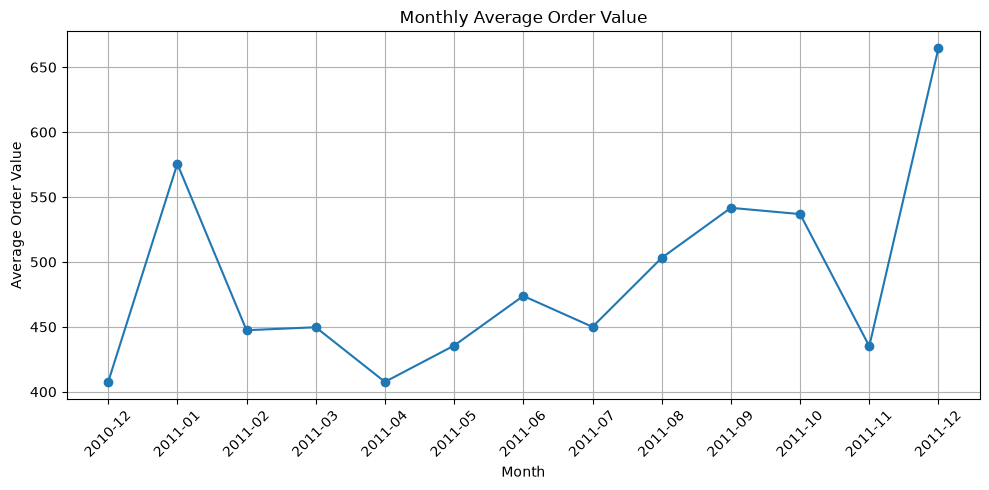

In [38]:
import matplotlib.pyplot as plt

monthly_aov = run_query("""
SELECT 
    strftime('%Y-%m', InvoiceDate) AS month,
    ROUND(SUM(TotalPrice) * 1.0 / COUNT(DISTINCT InvoiceNo), 2) AS average_order_value
FROM retail_sales
GROUP BY strftime('%Y-%m', InvoiceDate)
ORDER BY month;
""")

plt.figure(figsize=(10,5))
plt.plot(monthly_aov['month'], monthly_aov['average_order_value'], marker='o')
plt.title('Monthly Average Order Value')
plt.xlabel('Month')
plt.ylabel('Average Order Value')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig("images/monthly_aov.jpg", dpi=300)
plt.show()


Step 24.6: Plot and Save Monthly Revenue Chart


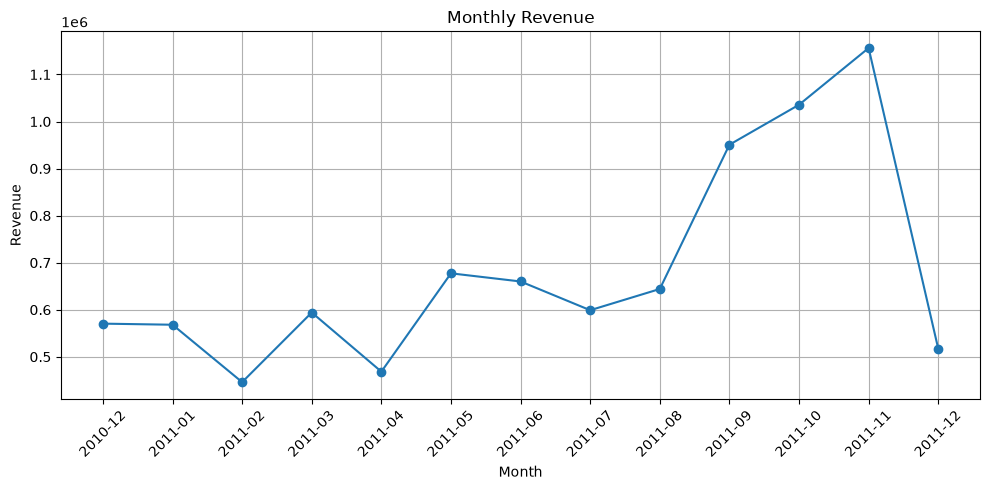

In [39]:
import matplotlib.pyplot as plt

monthly_revenue = run_query("""
SELECT 
    strftime('%Y-%m', InvoiceDate) AS month,
    ROUND(SUM(TotalPrice), 2) AS monthly_revenue
FROM retail_sales
GROUP BY strftime('%Y-%m', InvoiceDate)
ORDER BY month;
""")

plt.figure(figsize=(10,5))
plt.plot(monthly_revenue['month'], monthly_revenue['monthly_revenue'], marker='o')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig("images/monthly_revenue.jpg", dpi=300)
plt.show()


Step 24.7: Plot and Save Top 10 Products by Revenue Chart


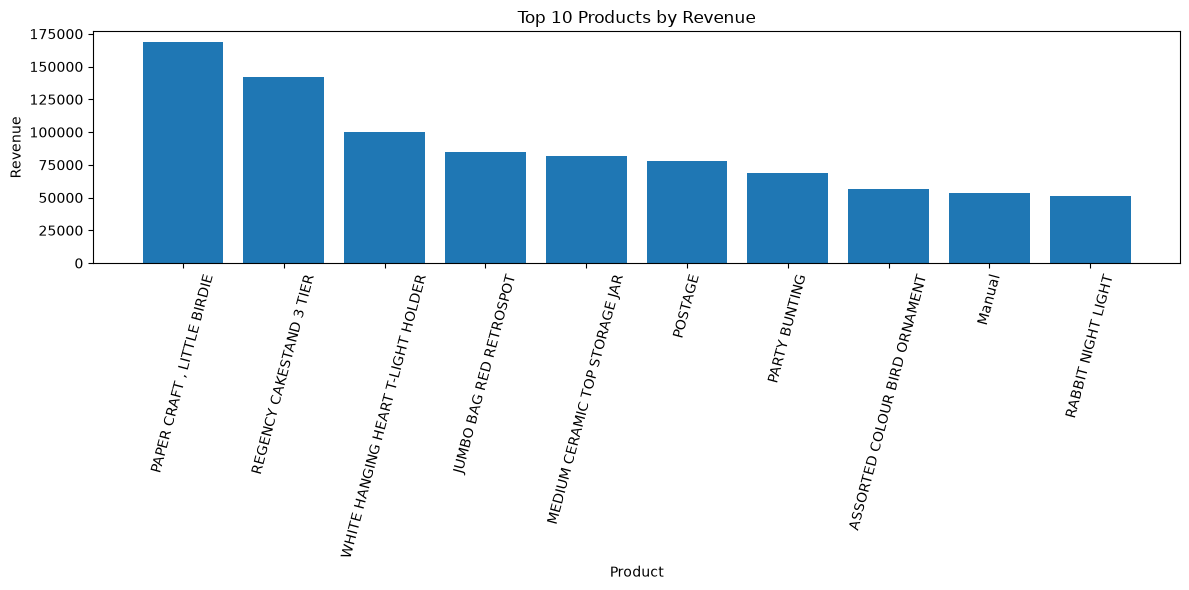

In [41]:
import matplotlib.pyplot as plt

top_products = run_query("""
SELECT 
    Description,
    ROUND(SUM(TotalPrice), 2) AS revenue
FROM retail_sales
GROUP BY Description
ORDER BY revenue DESC
LIMIT 10;
""")

plt.figure(figsize=(12,6))
plt.bar(top_products['Description'], top_products['revenue'])
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=75)
plt.tight_layout()

plt.savefig("images/top_10_products_by_revenue.jpg", dpi=300)
plt.show()


 Step 24.8: Plot and Save Revenue by Country Chart


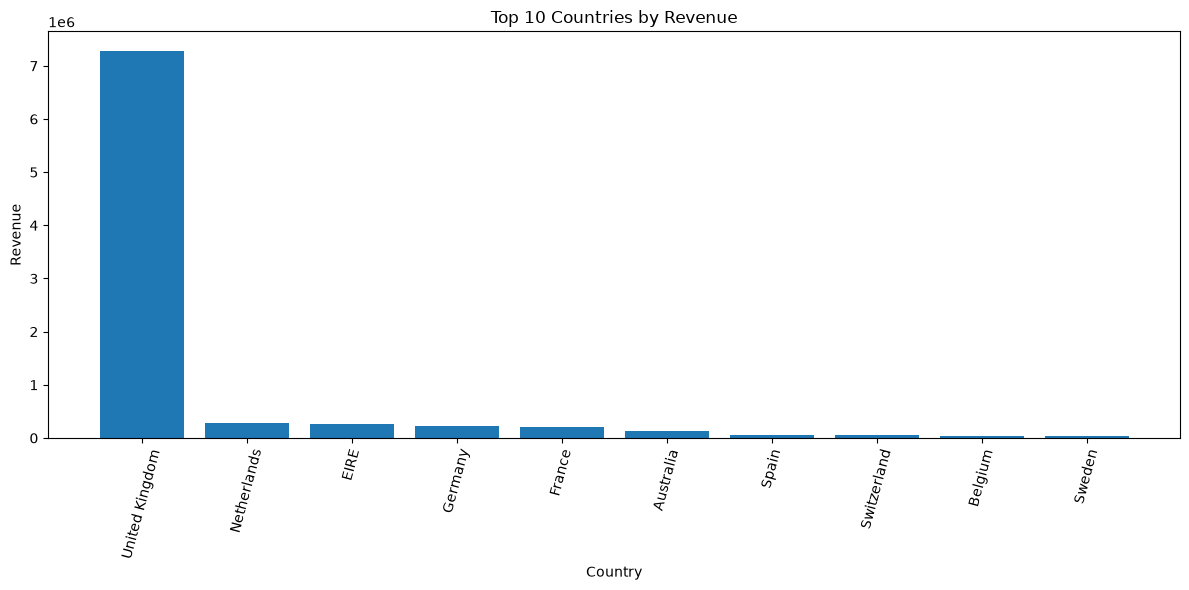

In [42]:
import matplotlib.pyplot as plt

country_revenue = run_query("""
SELECT 
    Country,
    ROUND(SUM(TotalPrice), 2) AS revenue
FROM retail_sales
GROUP BY Country
ORDER BY revenue DESC
LIMIT 10;
""")

plt.figure(figsize=(12,6))
plt.bar(country_revenue['Country'], country_revenue['revenue'])
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=75)
plt.tight_layout()

plt.savefig("images/revenue_by_country.jpg", dpi=300)
plt.show()


Step 24.9: Plot and Save Monthly AOV Chart


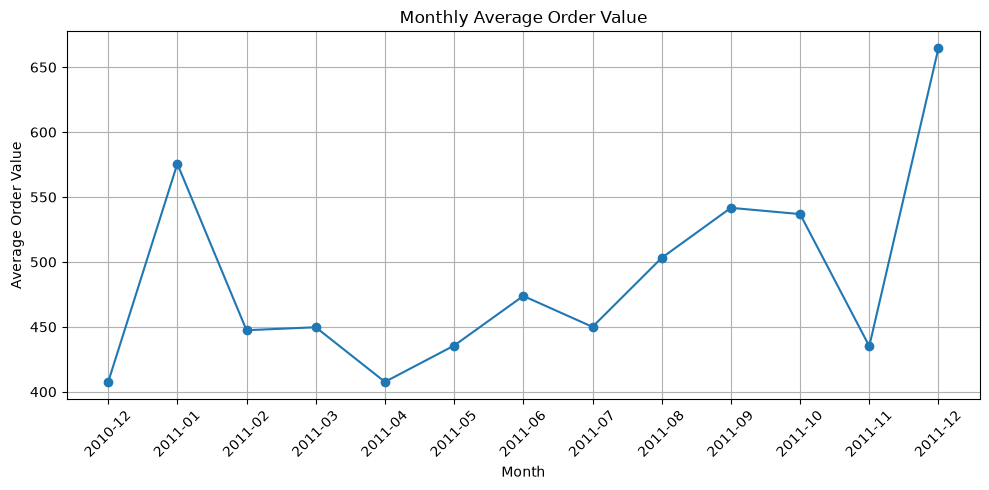

In [43]:
import matplotlib.pyplot as plt

monthly_aov = run_query("""
SELECT 
    strftime('%Y-%m', InvoiceDate) AS month,
    ROUND(SUM(TotalPrice) * 1.0 / COUNT(DISTINCT InvoiceNo), 2) AS average_order_value
FROM retail_sales
GROUP BY strftime('%Y-%m', InvoiceDate)
ORDER BY month;
""")

plt.figure(figsize=(10,5))
plt.plot(monthly_aov['month'], monthly_aov['average_order_value'], marker='o')
plt.title('Monthly Average Order Value')
plt.xlabel('Month')
plt.ylabel('Average Order Value')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig("images/monthly_aov.jpg", dpi=300)
plt.show()


Step 25: Check Saved Charts in images Folder


In [44]:
import os

os.listdir("images")


['monthly_aov.jpg',
 'monthly_revenue.jpg',
 'revenue_by_country.jpg',
 'top_10_products_by_revenue.jpg']

step 26: Set a Professional Chart Style


In [45]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")


Step 26.1: Replot and Save Top 10 Products by Revenue with Better Style


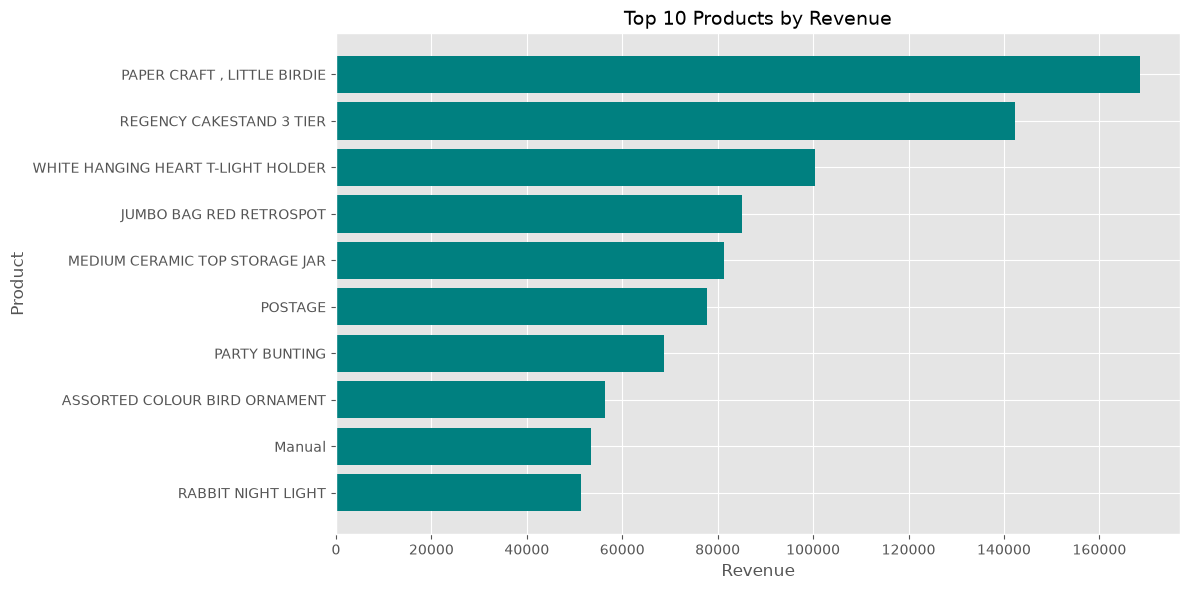

In [46]:
import matplotlib.pyplot as plt

top_products = run_query("""
SELECT 
    Description,
    ROUND(SUM(TotalPrice), 2) AS revenue
FROM retail_sales
GROUP BY Description
ORDER BY revenue DESC
LIMIT 10;
""")

plt.figure(figsize=(12,6))
plt.barh(top_products['Description'][::-1], top_products['revenue'][::-1], color='teal')
plt.title('Top 10 Products by Revenue', fontsize=14)
plt.xlabel('Revenue', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.tight_layout()

plt.savefig("images/top_10_products_by_revenue_styled.jpg", dpi=300)
plt.show()


 Step 26.2: Replot and Save Revenue by Country with Better Style


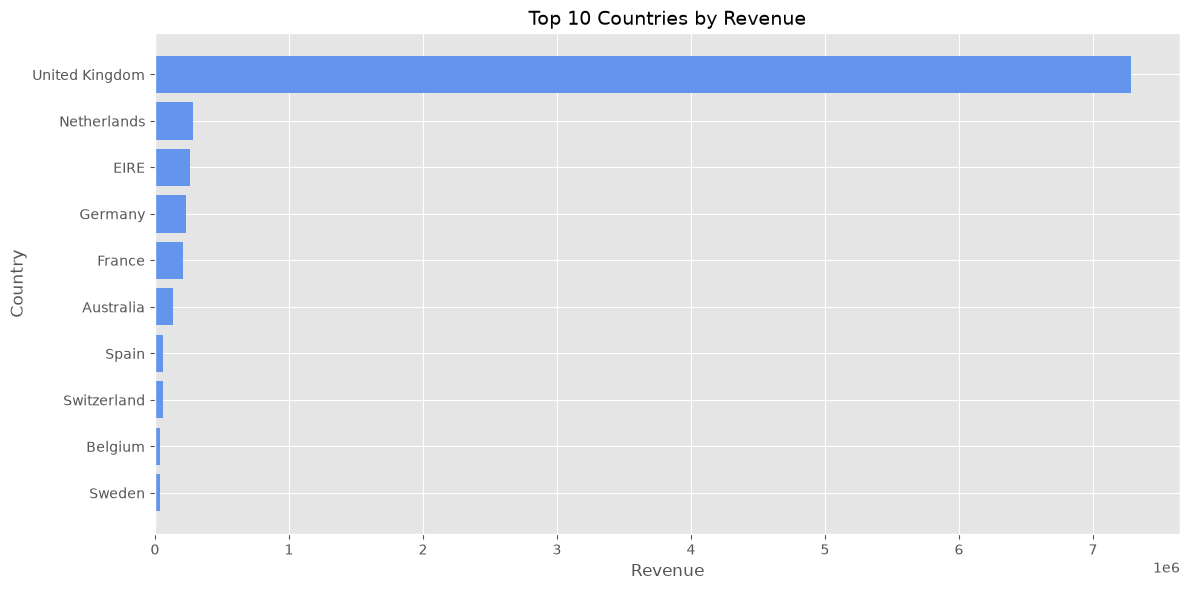

In [47]:
import matplotlib.pyplot as plt

country_revenue = run_query("""
SELECT 
    Country,
    ROUND(SUM(TotalPrice), 2) AS revenue
FROM retail_sales
GROUP BY Country
ORDER BY revenue DESC
LIMIT 10;
""")

plt.figure(figsize=(12,6))
plt.barh(country_revenue['Country'][::-1], country_revenue['revenue'][::-1], color='cornflowerblue')
plt.title('Top 10 Countries by Revenue', fontsize=14)
plt.xlabel('Revenue', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()

plt.savefig("images/revenue_by_country_styled.jpg", dpi=300)
plt.show()


Step 26.3: Replot and Save Monthly Revenue with Better Style


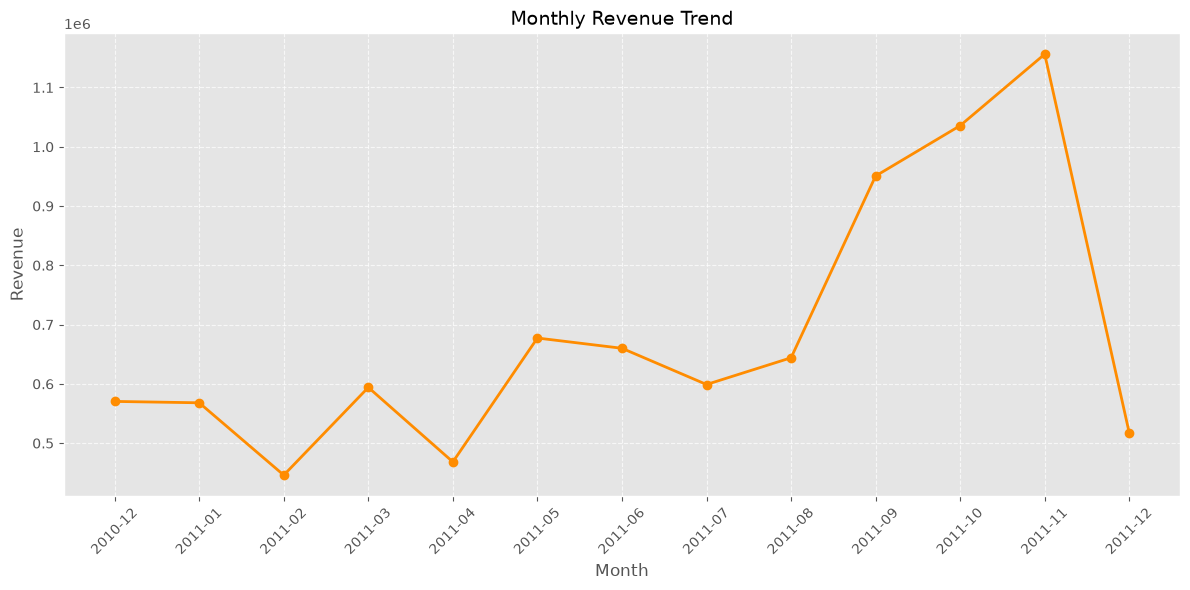

In [48]:
import matplotlib.pyplot as plt

monthly_revenue = run_query("""
SELECT 
    strftime('%Y-%m', InvoiceDate) AS month,
    ROUND(SUM(TotalPrice), 2) AS monthly_revenue
FROM retail_sales
GROUP BY strftime('%Y-%m', InvoiceDate)
ORDER BY month;
""")

plt.figure(figsize=(12,6))
plt.plot(
    monthly_revenue['month'],
    monthly_revenue['monthly_revenue'],
    marker='o',
    linewidth=2,
    color='darkorange'
)

plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("images/monthly_revenue_styled.jpg", dpi=300)
plt.show()


Step 26.4: Replot and Save Monthly AOV with Better Style


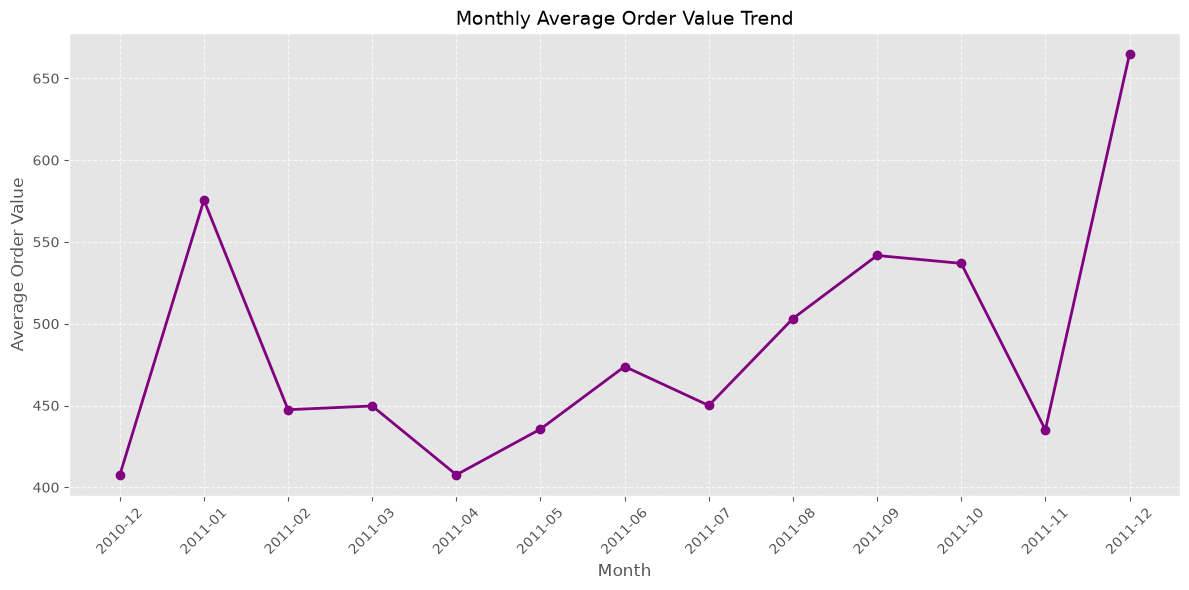

In [49]:
import matplotlib.pyplot as plt

monthly_aov = run_query("""
SELECT 
    strftime('%Y-%m', InvoiceDate) AS month,
    ROUND(SUM(TotalPrice) * 1.0 / COUNT(DISTINCT InvoiceNo), 2) AS average_order_value
FROM retail_sales
GROUP BY strftime('%Y-%m', InvoiceDate)
ORDER BY month;
""")

plt.figure(figsize=(12,6))
plt.plot(
    monthly_aov['month'],
    monthly_aov['average_order_value'],
    marker='o',
    linewidth=2,
    color='purple'
)

plt.title('Monthly Average Order Value Trend', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Order Value', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("images/monthly_aov_styled.jpg", dpi=300)
plt.show()


Step 27: OutPuts


In [51]:
import os

# ساخت پوشه outputs
os.makedirs("outputs", exist_ok=True)

# لیست فایل‌های SQL و نام خروجی CSV
query_files = {
    "queries/01_total_revenue.sql": "outputs/total_revenue.csv",
    "queries/02_total_orders.sql": "outputs/total_orders.csv",
    "queries/03_total_customers.sql": "outputs/total_customers.csv",
    "queries/04_top_products_by_revenue.sql": "outputs/top_10_products_by_revenue.csv",
    "queries/05_top_customers_by_revenue.sql": "outputs/top_10_customers_by_revenue.csv",
    "queries/06_revenue_by_country.sql": "outputs/revenue_by_country.csv",
    "queries/07_monthly_revenue_trend.sql": "outputs/monthly_revenue_trend.csv",
    "queries/08_monthly_aov.sql": "outputs/monthly_aov.csv",
    "queries/09_highest_aov_month.sql": "outputs/highest_aov_month.csv",
    "queries/10_lowest_aov_month.sql": "outputs/lowest_aov_month.csv"
}

# اجرای queryها و ذخیره خروجی با بررسی وجود فایل
for sql_file, output_file in query_files.items():
    if os.path.exists(sql_file):
        try:
            query = load_sql_query(sql_file)
            df_result = run_query(query)
            df_result.to_csv(output_file, index=False)
            print(f"Saved: {output_file}")
        except Exception as e:
            print(f"Error running {sql_file}: {e}")
    else:
        print(f"Skipped (file not found): {sql_file}")

print("\nDone.")
print("Files in outputs folder:")
print(os.listdir("outputs"))


Saved: outputs/total_revenue.csv
Saved: outputs/total_orders.csv
Saved: outputs/total_customers.csv
Saved: outputs/top_10_products_by_revenue.csv
Saved: outputs/top_10_customers_by_revenue.csv
Saved: outputs/revenue_by_country.csv
Saved: outputs/monthly_revenue_trend.csv
Skipped (file not found): queries/08_monthly_aov.sql
Saved: outputs/highest_aov_month.csv
Saved: outputs/lowest_aov_month.csv

Done.
Files in outputs folder:
['highest_aov_month.csv', 'lowest_aov_month.csv', 'monthly_revenue_trend.csv', 'revenue_by_country.csv', 'top_10_customers_by_revenue.csv', 'top_10_products_by_revenue.csv', 'total_customers.csv', 'total_orders.csv', 'total_revenue.csv']
